# Smart Phones Dataset Analysis

In [ ]:
# Import necessary libraries here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

You are provided with a data set names `smartphones.csv`. This dataset contains information about various smartphones and their specifications.

**Question :** Read dataset from `smartphones.csv` and assign this dataframe to `smartphoneData`. Print the first 5 rows of the dataset so you know what the data is like:

In [9]:
# Please write your code below
from google.colab import drive
drive.mount('/content/drive')

smartphoneData = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/DA1/smartphones.csv')

print(smartphoneData.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  brand_name                        Mdl     pc  rating  has_5g  has_nfc  \
0    oneplus              OnePlus 11 5G  54999    89.0    True     True   
1    oneplus  OnePlus Nord CE 2 Lite 5G  19989    81.0    True    False   
2    samsung      Samsung Galaxy A14 5G  16499    75.0    True    False   
3   motorola       Motorola Moto G62 5G  14999    81.0    True    False   
4     realme         Realme 10 Pro Plus  24999    82.0    True    False   

   has_ir_blaster processor_brand  num_cores  processor_speed  ...  \
0           False      snapdragon        8.0              3.2  ...   
1           False      snapdragon        8.0              2.2  ...   
2           False          exynos        8.0              2.4  ...   
3           False      snapdragon        8.0              2.2  ...   
4           False       dimensity        8.0              2.6  ...   


**Question 3:** In order to familiarize ourself with the dataset further, it is good to know the shape. Print the shape of the dataset and assign it to the variable `smartphoneDatashape`:

In [11]:
# printing shape of data
smartphoneDatashape = smartphoneData.shape
print("Shape of Data: \n",smartphoneDatashape)


Shape of Data: 
 (980, 26)


**Question :** Now that we know the shape of the dataset check if null values are present in it by writing a relevant code snippet that would do the job for you. Store the number of rows with null values, if any, in the variable `smartphoneDfNull`.

In [12]:
# check nulls

#storing number of rows with null values, if any in the variable smartphoneDfNull
smartphoneDfNull = smartphoneData.isnull().any(axis=1).sum()
print("Null values in Dataset: \n",smartphoneDfNull)


Null values in Dataset: 
 628


**Question 5a:** If you found any null values (missing values) from the code above, replace all those values with the average value in their respective columns. Do this only for columns containing numeric values. You are allowed to use the built-in mean() function here.

In [14]:
# Replacing nulls with average value in respective column
# choosing numeric columns

numeric_cols = smartphoneData.select_dtypes(include='number')

for col in numeric_cols.columns:
  numeric_cols[col].fillna(numeric_cols[col].mean(), inplace=True)
print("Nulls replaced with average values: \n",numeric_cols)


Nulls replaced with average vlues: 
         pc  rating  num_cores  processor_speed  battery_capacity  \
0    54999    89.0        8.0         3.200000            5000.0   
1    19989    81.0        8.0         2.200000            5000.0   
2    16499    75.0        8.0         2.400000            5000.0   
3    14999    81.0        8.0         2.200000            5000.0   
4    24999    82.0        8.0         2.600000            5000.0   
..     ...     ...        ...              ...               ...   
975  34990    83.0        8.0         3.000000            5000.0   
976  14990    75.0        8.0         2.200000            5000.0   
977  28990    85.0        8.0         2.850000            5080.0   
978  19990    80.0        8.0         2.200000            5000.0   
979  24990    74.0        8.0         2.427217            5000.0   

     fast_charging_available  fast_charging  ram_capacity  internal_memory  \
0                          1     100.000000            12           

/tmp/ipykernel_1123/3214459778.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  numeric_cols[col].fillna(numeric_cols[col].mean(), inplace=True)


Now for the rows that still have null values (in the non-numeric columns), drop these rows from the dataframe

In [15]:
# Dropping nulls if still exists

# choosing non numeric columns
non_numeric_cols = smartphoneData.select_dtypes(exclude='number').columns

# dropping null values
smartphoneData = smartphoneData.dropna(subset=non_numeric_cols)
#print(smartphoneData)

**Question :** A good data scientist needs to be able to justify his/her choices. Do you think this was a good way of dealing with missing values? Why or why not?

#How to handle missing values
Missing values should be handled with caution, as deleting them may be beneficial in some situations and harmful in others. If only a very small number of rows contain missing values, and their removal does not introduce bias, deletion can be a reasonable approach. However, if a large proportion of the data is missing, deleting those records may reduce the quality of the dataset and lead to biased results. Therefore, missing data should be addressed using clear guidelines. First, the type and amount of missingness should be identified. Second, data should not be deleted unless it is safe to do so. Third, imputation should be selected according to the variable type and the missingness pattern. Fourth, missing value indicators may be created when they add analytical value. Fifth, scikit learn imputation tools can be used within preprocessing pipelines for more reliable implementation. Finally, the selected method should always be justified in relation to the dataset and the purpose of the study.

#Guidelines for handling missing values are as follows:



*   Identify the type and extent of missingness in the dataset.
*   Avoid deleting rows or columns unless it is clearly safe and will not introduce bias.
*   Apply imputation methods according to the variable type and the pattern of missingness.
*   Track missing values where their presence may provide useful information.
*   Use scikit learn tools for pipeline based imputation to improve consistency and reproducibility.
*   Always justify the chosen method based on the dataset characteristics and analysis goals.

**Question :** While going through the dataframe, you might have noticed some discrepancies in the column names. We will rename these columns so that we can make more sense out of the data and comprehend it in a better way. The following column changes must be reflected in the dataframe.
<ul>

<li>Mdl --> model</li>
<li> pc --> price</li>
<li>reso --> res </li>
 <li> primary_camera_rear --> rear_megapixels</li>
     <li> primary_camera_front --> front_megapixels</li>
</ul>

You should also drop the `rating` column.

In [20]:

# renaming coloumns for better readability
smartphoneData = smartphoneData.rename(columns={'Mdl': 'model','pc': 'price', 'reso':'res' , 'primary_camera_rear':'rear_megapixels', 'primary_camera_front':'front_megapixels'})

# deleting coloumn in dataset named 'rating'
if "rating" in smartphoneData.columns:
    smartphoneData = smartphoneData.drop(columns=['rating'])

print(smartphoneData.columns)



Index(['brand_name', 'model', 'price', 'has_5g', 'has_nfc', 'has_ir_blaster',
       'processor_brand', 'num_cores', 'processor_speed', 'battery_capacity',
       'fast_charging_available', 'fast_charging', 'ram_capacity',
       'internal_memory', 'screen_size', 'refresh_rate', 'res',
       'num_rear_cameras', 'num_front_cameras', 'os', 'rear_megapixels',
       'front_megapixels', 'extended_memory_available', 'extended_upto',
       'faulty'],
      dtype='object')


**Question :** There are some columns which have values of either `True` or `False`. Write a code snippet to replace these values with a 1 or a 0 respectively.

In [21]:
# Replacing true or false with 0 or 1

# initiating a loop to check any true or false in columns of datasetand replacing it with respective 0 or 1
for columns in smartphoneData.columns:
    if smartphoneData[columns].dtype == bool:
        smartphoneData[columns] = smartphoneData[columns].astype(int)

print(smartphoneData.head())

  brand_name                      model  price  has_5g  has_nfc  \
0    oneplus              OnePlus 11 5G  54999       1        1   
1    oneplus  OnePlus Nord CE 2 Lite 5G  19989       1        0   
2    samsung      Samsung Galaxy A14 5G  16499       1        0   
3   motorola       Motorola Moto G62 5G  14999       1        0   
4     realme         Realme 10 Pro Plus  24999       1        0   

   has_ir_blaster processor_brand  num_cores  processor_speed  \
0               0      snapdragon        8.0              3.2   
1               0      snapdragon        8.0              2.2   
2               0          exynos        8.0              2.4   
3               0      snapdragon        8.0              2.2   
4               0       dimensity        8.0              2.6   

   battery_capacity  ...  refresh_rate           res  num_rear_cameras  \
0            5000.0  ...           120  1440 x 3216                  3   
1            5000.0  ...           120  1080 x 2412       

**Question :** Now that we have understood the whole dataframe and tweaked it up to make it more comprehensible, set the index of the data frame to `brand_name`

In [32]:
# making brand_name the index column
smartphoneData = smartphoneData.set_index("brand_name")

print("Index is 'brand_name' ")

Index is 'brand_name' 


**Question :** Saad needs to buy a new phone and as a data scientist, he has selected you to help him make a decision. His maximum budget is 50,000 rupees. However, he does not want to trade off quality for a phone that is too cheap. Filter out all the phones that fall within his budget constraint but also cost at least 15,000 rupees, and store it in the variable `filteredPhones`.

In [33]:

# Filtered Phones
filteredPhones = smartphoneData[(smartphoneData["price"]>=15000) & (smartphoneData["price"] <=50000)]

print(filteredPhones)

                                              model  price  has_5g  has_nfc  \
brand_name                                                                    
oneplus                   OnePlus Nord CE 2 Lite 5G  19989       1        0   
samsung                       Samsung Galaxy A14 5G  16499       1        0   
realme                           Realme 10 Pro Plus  24999       1        0   
samsung     Samsung Galaxy F23 5G (6GB RAM + 128GB)  16999       1        1   
xiaomi                Xiaomi Redmi Note 12 Pro Plus  29999       1        0   
...                                             ...    ...     ...      ...   
motorola                        Motorola ThinkPhone  49990       1        1   
xiaomi                                Xiaomi Civi 3  32990       1        1   
motorola                 Motorola Moto Edge S30 Pro  34990       1        0   
poco                POCO X4 GT 5G (8GB RAM + 256GB)  28990       1        1   
motorola                       Motorola Moto G91 5G 

**Question :** Next, saad gives you a list which contains preference values for certain smartphone features:

| feature | preference value |
|-----|-----|
| number of cores | 3 |
| battery capacity | 5 |
| screen size | 2 |
| refresh rate | 3 |
| ram capacity | 4 |
| internal memory | 5 |
| processor speed | 4 |
| rear camera megapixels | 3 |
| front camera megapixels | 2 |

Write a function `calculate` that takes a full row from the filtered dataset as a parameter and returns the score for the phone in that row by multiplying the preference values with the corresponding characterstics. **Hint:** There is a certain function which helps you print all column names in order (just in case you need to find their index)

In [35]:
#
#generating feature, preference table
features_preference = {
    "num_cores" : 3,
    "battery_capacity" : 5,
    "screen_size" : 2,
    "refresh_rate" : 3,
    "ram_capacity" : 4,
    "internal_memory" : 5,
    "processor_speed" : 4,
    "rear_megapixels" : 3,
    "front_megapixels" : 2,
}

# calculting score based on features and preferences
def calculate(row):
  score = 0
  for feature, preference in features_preference.items():
    if feature in row:
      score += row[feature] * preference
  return score

filteredPhones = filteredPhones.copy()
filteredPhones['score'] = filteredPhones.apply(calculate, axis=1)
print(filteredPhones[['model','score']].head())


                                              model     score
brand_name                                                   
oneplus                   OnePlus Nord CE 2 Lite 5G  26293.98
samsung                       Samsung Galaxy A14 5G  25828.80
realme                           Realme 10 Pro Plus  26427.80
samsung     Samsung Galaxy F23 5G (6GB RAM + 128GB)  26236.00
xiaomi                Xiaomi Redmi Note 12 Pro Plus  27251.74


**Question ** Make a new dataframe with scores for each of the filtered phones along with their price, os and processor brand . Note: Order should be `score`, `price`, `os`,`processor_brand` with `model` as index. Assign it to `phoneScores`.

In [36]:
# Please write your code below

filteredPhones = filteredPhones[['score','price', 'os', 'processor_brand','model']]
phoneScores = filteredPhones.copy()
set_index = phoneScores.set_index('model')

print(phoneScores.columns.to_list())

['score', 'price', 'os', 'processor_brand', 'model']


**Question ** Using a pivot table, count the number of different processor brands each operating system (os) has. **Note:** Keep the operating system as the column. Assign the pivot table to the variable `pivotTable`

In [37]:
# pivot table
pivotTable = phoneScores.pivot_table(index='processor_brand', columns='os', values='model', aggfunc='nunique',fill_value=0)

print(pivotTable)

os               android  ios  other
processor_brand                     
bionic                 0    8      0
dimensity            139    0      0
exynos                28    0      0
google                 3    0      0
helio                 45    0      0
kirin                  1    0      0
snapdragon           248    0      4


**Question ** Using the phoneScores dataframe, Saad wants you to check for the most popular processor brand. Create a horizontal bar plot, where the y-axis contains each processor brand and the x-axis contains the number of phones using that brand of processor. Then write a code snippet to find the most popular brand and store this in the variable `most_popular_processor`

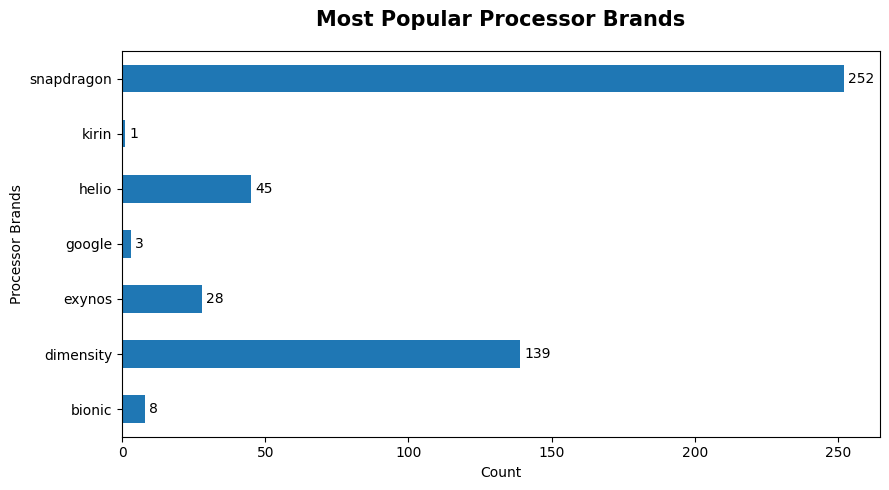

Most Popular Processor Brand:  snapdragon


In [38]:
# Please write your code below

# finding the most popular processor brand
processor_total_phones = pivotTable.sum(axis=1)
most_popular_processor = processor_total_phones.idxmax()

#Horizontal bar plot
bar_plot = processor_total_phones.plot(kind='barh',figsize=(9,5))
bar_plot.bar_label(bar_plot.containers[0], label_type='edge', padding=3)

# labeling X and Y axis and giving heading to graph
plt.title('Most Popular Processor Brands',fontsize=15,fontweight='bold',loc='center',pad=18)
plt.xlabel('Count')
plt.ylabel('Processor Brands')

#graph display
plt.tight_layout()
plt.show()

# Printing name of most popular processing brand
print("Most Popular Processor Brand: ", most_popular_processor)


**Question 9f** Saad now decides that he only wants an android phone with the most popular processor. Filter your results from the `phoneScores` dataframe to find phones with android operating systems and the processor brand you shortlisted in Q9e and store them in the variable `androidPhones`.

In [40]:
# Please write your code below

androidPhones = phoneScores[(phoneScores['os'].str.lower() == 'android') & (phoneScores['processor_brand'] == most_popular_processor)]
print(androidPhones)

               score  price       os processor_brand  \
brand_name                                             
oneplus     26293.98  19989  android      snapdragon   
samsung     26236.00  16999  android      snapdragon   
nothing     23761.10  26749  android      snapdragon   
realme      26426.24  18999  android      snapdragon   
vivo        26251.96  16990  android      snapdragon   
...              ...    ...      ...             ...   
samsung     18009.60  39990  android      snapdragon   
motorola    23868.14  42990  android      snapdragon   
motorola    26368.00  49990  android      snapdragon   
motorola    26305.34  34990  android      snapdragon   
motorola    26278.40  19990  android      snapdragon   

                                              model  
brand_name                                           
oneplus                   OnePlus Nord CE 2 Lite 5G  
samsung     Samsung Galaxy F23 5G (6GB RAM + 128GB)  
nothing                             Nothing Phone 1  
r

**Question ** Finally, from these filtered android phones, find out the top 5 phones with the highest scores. Plot a bar chart for these phones with their model on the x axis and price on the y axis.

Top 5 phones with highest scores:                 score  price       os processor_brand                     model
brand_name                                                                    
nokia       32401.80  46999  android      snapdragon              Nokia N73 5G
nokia       31817.82  49990  android      snapdragon          Nokia X60 Pro 5G
motorola    31458.76  15999  android      snapdragon         Motorola Moto G60
asus        31393.16  39999  android      snapdragon      Asus ROG Phone 5s 5G
nubia       31264.40  46990  android      snapdragon  Nubia Red Magic 8 Pro 5G


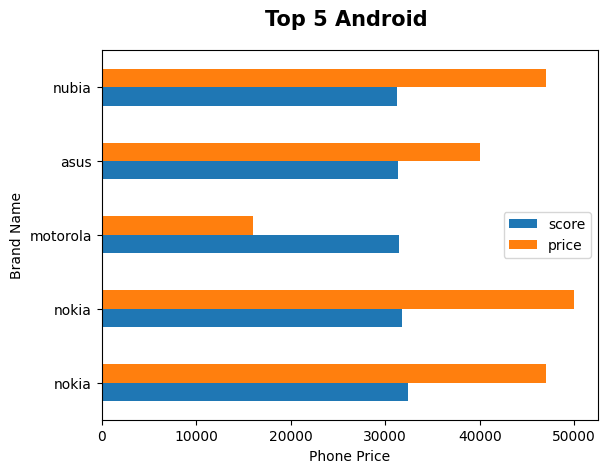

In [41]:
# Please write your code below
top_5_phones = androidPhones.sort_values(by='score',ascending=False).head(5)
print("Top 5 phones with highest scores: ", top_5_phones )

# bar chart showing models and prices for top 5 phones
top_5_phones_plot = top_5_phones.plot(kind='barh')
bar_plot.bar_label(top_5_phones_plot.containers[0], label_type='edge', padding=3)

plt.title('Top 5 Android ',fontsize=15,fontweight='bold',loc='center',pad=18)
plt.xlabel('Phone Price')
plt.ylabel('Brand Name')
#plt.tight_layout()
plt.show()



**Question ** From these top 5 phones, Saad wants to buy the cheapest one. Use a python function to find the cheapest phone from these top 5 phones. Then visually find the cheapest phone from your bar chart. Do they match? If so, store the model name in the variable `finalPhone`.

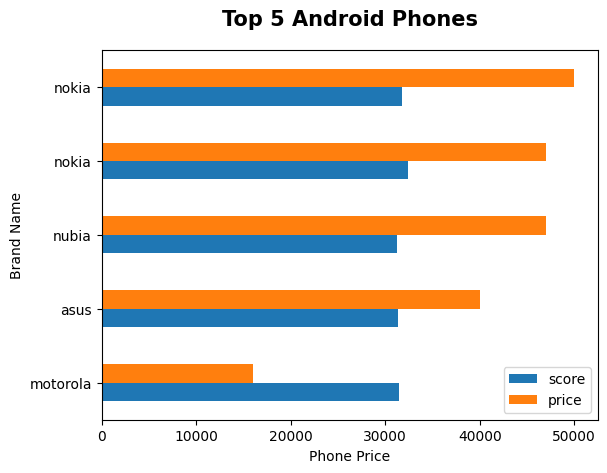

Cheapest Phone:  Motorola Moto G60


In [42]:
# Please write your code below

#Finding cheapest phone
top_5_cheap_phones = top_5_phones.sort_values(by='price',ascending=True).head(5)
cheapest_phone = top_5_phones[(top_5_phones['price'] == top_5_phones['price'].min())]

# bar chart to show top 5 low price phones

top_5_cheap_phones_plot = top_5_cheap_phones.plot(kind='barh')
bar_plot.bar_label(top_5_cheap_phones_plot.containers[0], label_type='edge', padding=3)

plt.title('Top 5 Android Phones',fontsize=15,fontweight='bold',loc='center',pad=18)
plt.xlabel('Phone Price')
plt.ylabel('Brand Name')
#plt.tight_layout()
plt.show()

#Storing model name in variable finalPhone
finalPhone = cheapest_phone['model'].values[0]
print("Cheapest Phone: ", finalPhone)


# According to bar chart, cheapest phone is of Motorola brand, which is Motorola Moto G60.
# So visualy and in calculations the final cheapest phone is same, which is Motorola Moto G60.


**Question 10** Using the original dataset `smartPhoneData`, find out if the average price of Android phones is higher than apple (ios) Phones. Make a variable names `higher_price` and store the string `Yes` or `No` in it depending on your answer. `Yes` indicating that Android phones are more expensive, on average.

In [46]:
# Please write your code below

#checking if average price of ANDROID IS MORE THAN THAT OF IOS IN SMARTPHONES DATASET usig group by clause

avg_price = smartphoneData.groupby(['os'])['price'].mean()
android_avg_price = avg_price.get('android',0)
ios_avg_price = avg_price.get('ios',0)

higher_price = 'Yes' if android_avg_price > ios_avg_price else 'No'

print("'",higher_price,"'" ,"for statement that 'android price is higher than ios price' ")


' No ' for statement that 'android price is higher than ios price' 


**Question ** How many phones have a price and battery capacity below the thresholds mentioned below? Store it in the variable `numberOfPhones`. (Use the original dataset)
<br>
The column `faulty` in the original dataset indicates if a phone has known faults or not. `1` indicates there are known faults and `0` indicates there are no known faults.
Do you think phones with a lower price and battery capacity than the threshold have a higher probability of getting a fault? Justify this claim by providing a valid analysis.

In [ ]:
priceThreshold = 50000
batteryThreshold = 3000


# Getting below threshold phone count and mean of below threshold faulty phones

numberOfPhones = smartphoneData[(smartphoneData['price'] < priceThreshold) & (smartphoneData['battery_capacity'] < batteryThreshold)]['faulty'].count()
print("Below Threshold Phones: ", numberOfPhones)
BelowThreshold = smartphoneData[(smartphoneData['price'] < priceThreshold) & (smartphoneData['battery_capacity'] < batteryThreshold)]['faulty'].mean()
print("Below Threshold Faulty Phones Mean: ", BelowThreshold)

# Getting above threshold phone count and mean of above threshold faulty phones

numberOfAbovePhones = smartphoneData[(smartphoneData['price'] > priceThreshold) & (smartphoneData['battery_capacity'] > batteryThreshold)]['faulty'].count()
print("Above Threshold Phones: ", numberOfAbovePhones)
AboveThreshold = smartphoneData[(smartphoneData['price'] > priceThreshold) & (smartphoneData['battery_capacity'] > batteryThreshold)]['faulty'].mean()
print("Above Threshold Faulty Phones Mean: ", AboveThreshold)


## Provide an explanation for your answer below
# By looking at mean we can say that phones with lowwr price and battery capacity than the threshold have a higher probabilty of getting a fault.
# This compromise of quality could be the result of cost-cutting startegy

Below Threshold Phones:  8
Below Threshold Faulty Phones Mean:  0.125
Above Threshold Phones:  137
Above Threshold Faulty Phones Mean:  0.20437956204379562


An examination of the mean values indicates that phones with lower prices and battery capacities, relative to the established threshold, are more likely to experience faults. This may reflect a trade off in product quality, possibly due to cost cutting measures implemented in production.